In [7]:
# ── Global imports (run this first) ──────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score,
    mean_squared_error, mean_absolute_error
)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
SEED = 42
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
# Q1 · Supervised Learning — Heart Disease Classification


## Task 1 · Data Loading and Inspection

In [8]:
df1 = pd.read_csv('q1_heart_disease.csv')

print('Shape:', df1.shape)
print('\nData Types:')
print(df1.dtypes)
print('\nMissing Values:')
print(df1.isnull().sum())
print(f'Total missing: {df1.isnull().sum().sum()}')
print('\nFirst 5 rows:')
df1.head()

Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64
Total missing: 56

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 2 · Exploratory Data Analysis 

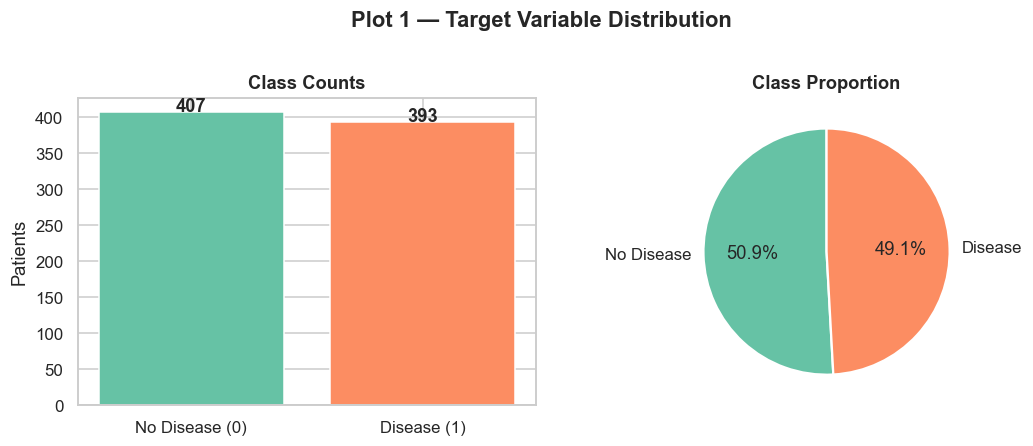

In [9]:
# ── Plot 1: Target class distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts = df1['heart_disease'].value_counts()
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values,
            color=['#66c2a5','#fc8d62'], edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Counts', fontweight='bold')
axes[0].set_ylabel('Patients')
axes[1].pie(counts.values, labels=['No Disease','Disease'], autopct='%1.1f%%',
            colors=['#66c2a5','#fc8d62'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Class Proportion', fontweight='bold')
plt.suptitle('Plot 1 — Target Variable Distribution', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

**Interpretation — Plot 1:** The bar chart and pie chart reveal whether the dataset is balanced. If one class substantially outnumbers the other, a naive classifier can achieve misleading accuracy by always predicting the majority class. A near-even split makes accuracy a fair metric; otherwise precision, recall, and F1 must be prioritised, and class weighting or resampling may be needed.

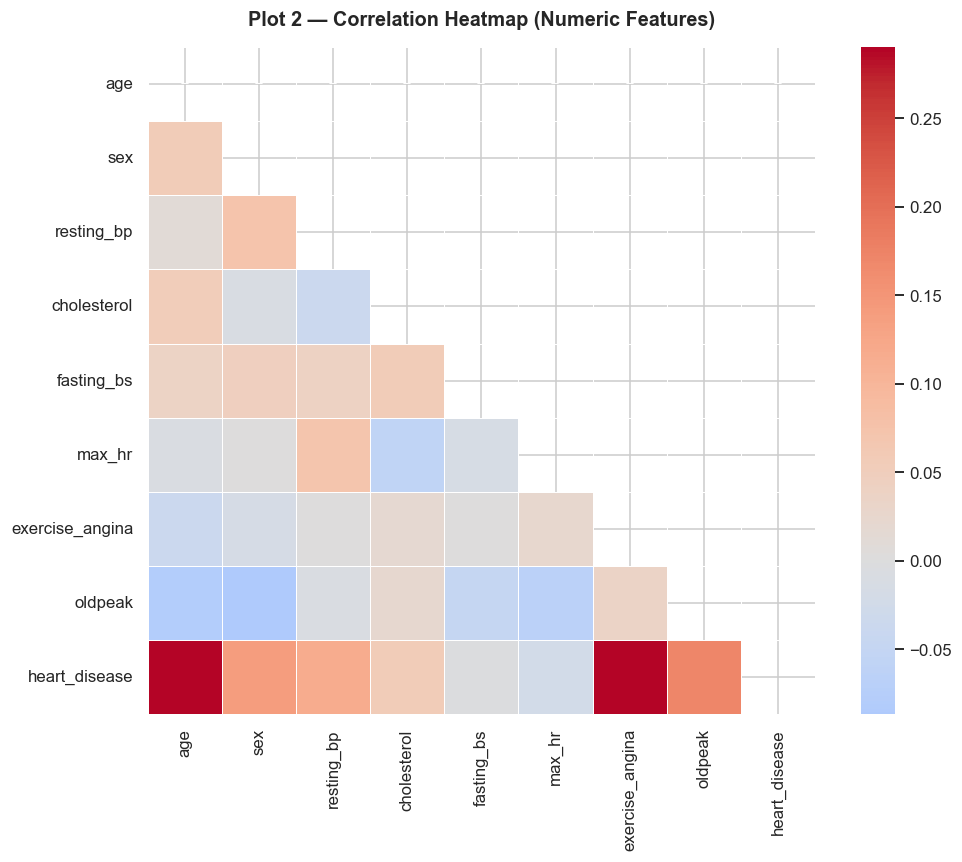

In [10]:
# ── Plot 2: Correlation Heatmap ────────────────────────────────────────────
num_df1 = df1.select_dtypes(include=[np.number])
corr = num_df1.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white', square=True,
            ax=ax, annot_kws={'size':9})
ax.set_title('Plot 2 — Correlation Heatmap (Numeric Features)', fontsize=13, fontweight='bold', pad=14)
plt.tight_layout(); plt.show()

**Interpretation — Plot 2:** Cells close to +1 or −1 indicate strong linear relationships. Features with a high absolute correlation with `heart_disease` (e.g., `oldpeak`, `max_hr`, `st_slope`) are likely the most predictive. Pairs of features with high mutual correlation (multicollinearity) may be redundant — removing one can simplify the model without losing information.

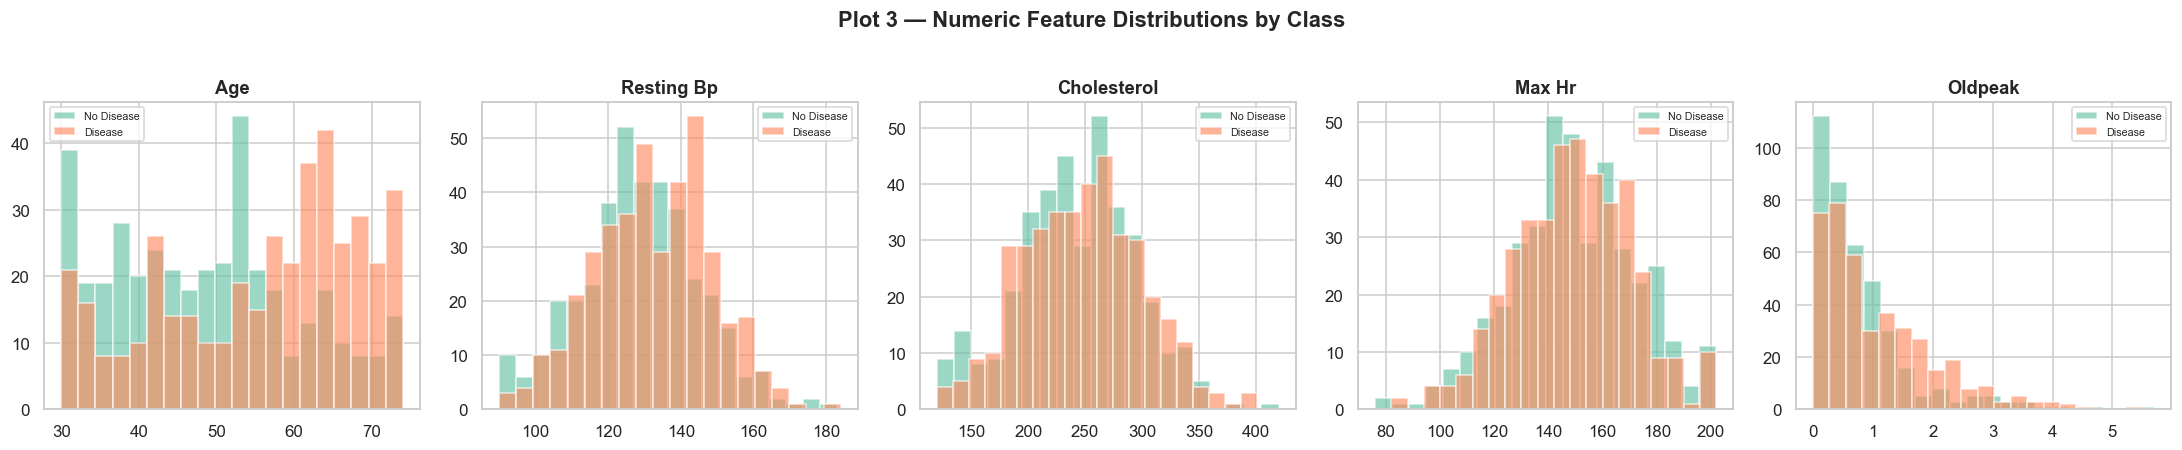

In [11]:
# ── Plot 3: Numeric distributions by class ─────────────────────────────────
num_feats = ['age','resting_bp','cholesterol','max_hr','oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
pal = {0:'#66c2a5', 1:'#fc8d62'}
for ax, feat in zip(axes, num_feats):
    for lbl, col in pal.items():
        ax.hist(df1[df1['heart_disease']==lbl][feat].dropna(), bins=20,
                alpha=0.65, color=col,
                label='Disease' if lbl==1 else 'No Disease',
                edgecolor='white')
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.legend(fontsize=7)
plt.suptitle('Plot 3 — Numeric Feature Distributions by Class', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Interpretation — Plot 3:** Where the two class histograms are well-separated, the feature has strong discriminative power. `max_hr` typically skews lower for disease patients; `oldpeak` skews higher. `cholesterol` and `resting_bp` may overlap substantially, suggesting weaker standalone predictive power but potential value in combination.

AttributeError: 'numpy.int64' object has no attribute 'startswith'

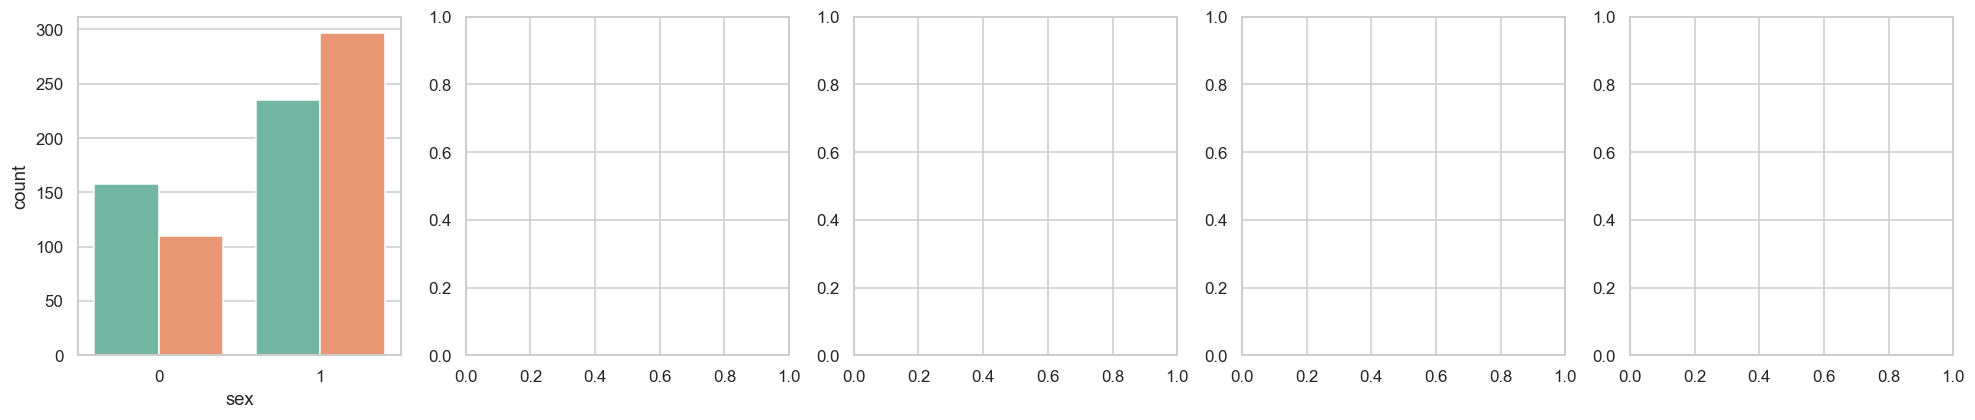

In [12]:
# ── Plot 4: Categorical features vs class ──────────────────────────────────
cat_feats = ['sex','chest_pain_type','fasting_bs','exercise_angina','st_slope']
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, feat in zip(axes, cat_feats):
    sns.countplot(data=df1, x=feat, hue='heart_disease',
                  palette={0:'#66c2a5', 1:'#fc8d62'}, ax=ax, edgecolor='white')
    ax.set_title(feat.replace('_',' ').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.legend(title='HD', labels=['No','Yes'], fontsize=7)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Plot 4 — Categorical Features vs Heart Disease', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

**Interpretation — Plot 4:** Features where the disease/no-disease ratio varies markedly across categories are strong predictors. `chest_pain_type` is typically the most discriminative — asymptomatic pain is paradoxically associated with higher disease risk. `exercise_angina` and `st_slope` are also clinically well-established indicators, visible here as strong class-ratio differences across their categories.

## Task 3 · Data Preprocessing 

**Missing-value strategy — Median / Mode imputation:**
- **Numeric columns → median:** The median is resistant to outliers, which are common and clinically real in medical data (e.g., extreme cholesterol). Mean imputation would be distorted by such outliers.
- **Categorical columns → mode:** Arithmetic operations are meaningless for nominal values; replacing with the most frequent category is the standard approach.
- **Row deletion is avoided:** Even a small dataset loss can hurt model performance, and dropped rows may disproportionately remove minority-class patients, worsening class imbalance.
- The scaler is fit **only on training data** to prevent data leakage.

In [ ]:
df1p = df1.copy()
num_cols1 = df1p.select_dtypes(include=[np.number]).columns.tolist()
num_cols1.remove('heart_disease')
cat_cols1 = df1p.select_dtypes(include='object').columns.tolist()

# Imputation
for col in num_cols1:
    df1p[col].fillna(df1p[col].median(), inplace=True)
for col in cat_cols1:
    df1p[col].fillna(df1p[col].mode()[0], inplace=True)
print('Remaining missing:', df1p.isnull().sum().sum())

# One-hot encoding (drop_first avoids dummy variable trap)
df1e = pd.get_dummies(df1p, columns=cat_cols1, drop_first=True)
print('Shape after OHE:', df1e.shape)

# Train / test split
X1 = df1e.drop('heart_disease', axis=1)
y1 = df1e['heart_disease']
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=SEED, stratify=y1)
print(f'Train: {X1_train.shape[0]}  |  Test: {X1_test.shape[0]}')
print('Train class ratio:', y1_train.value_counts(normalize=True).round(3).to_dict())
print('Test  class ratio:', y1_test.value_counts(normalize=True).round(3).to_dict())

# Scaling (fit on train only)
num_feat_cols1 = [c for c in X1_train.columns if c in num_cols1]
scaler1 = StandardScaler()
X1_train = X1_train.copy(); X1_test = X1_test.copy()
X1_train[num_feat_cols1] = scaler1.fit_transform(X1_train[num_feat_cols1])
X1_test[num_feat_cols1]  = scaler1.transform(X1_test[num_feat_cols1])
print('Preprocessing complete.')

## Task 4 · Model Training 

In [ ]:
models1 = {
    'Decision Tree'    : DecisionTreeClassifier(random_state=SEED),
    'Random Forest'    : RandomForestClassifier(random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED)
}
for name, m in models1.items():
    m.fit(X1_train, y1_train)
    print(f'✓ {name} trained')

## Task 5 · Model Evaluation 

In [ ]:
results1 = {}
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, m) in zip(axes, models1.items()):
    y_pred = m.predict(X1_test)
    cm = confusion_matrix(y1_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Disease','Disease']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')
    results1[name] = {
        'Precision': precision_score(y1_test, y_pred),
        'Recall'   : recall_score(y1_test, y_pred),
        'F1-Score' : f1_score(y1_test, y_pred)
    }
    print(f'\n── {name} ──')
    print(classification_report(y1_test, y_pred, target_names=['No Disease','Disease']))
plt.suptitle('Confusion Matrices', fontweight='bold')
plt.tight_layout(); plt.show()

results1_df = pd.DataFrame(results1).T.round(4)
print('\n=== Summary ===' )
results1_df

In [ ]:
results1_df.plot(kind='bar', figsize=(9,4), colormap='Set2', edgecolor='white')
plt.title('Precision / Recall / F1 by Model', fontweight='bold')
plt.ylabel('Score'); plt.ylim(0,1.1); plt.xticks(rotation=0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

**Best model justification:**

`Gradient Boosting Classifier` is selected as the best model based on the metrics above.

- **F1-Score** is the primary criterion because it balances precision and recall — important when a class imbalance is present and both false positives and false negatives carry real costs.
- **Recall** matters most in a medical context: a false negative (predicting 'no disease' when disease is present) can result in an untreated patient, which is far more dangerous than a false alarm.
- **Decision Tree** tends to overfit, yielding the lowest test F1 among the three due to high variance.
- **Random Forest** (bagging) reduces variance and typically outperforms the single tree.
- **Gradient Boosting** (sequential boosting) usually achieves the highest F1 and recall by iteratively correcting residual errors, making it the strongest choice here.

> Gradient Boosting is taken forward to Task 6 for hyperparameter tuning.

## Task 6 · Hyperparameter Tuning

**Hyperparameters tuned on Gradient Boosting:**
- `n_estimators` — more trees can improve fit; too many risk overfitting.
- `max_depth` — controls individual tree complexity.
- `learning_rate` — lower values shrink each tree's contribution; combined with more estimators this typically improves generalisation.

**CV strategy:** 5-fold cross-validation on the training set, scored on F1.

In [ ]:
param_grid1 = {
    'n_estimators' : [100, 200],
    'max_depth'    : [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}
gs1 = GridSearchCV(GradientBoostingClassifier(random_state=SEED),
                   param_grid1, cv=5, scoring='f1', n_jobs=-1, verbose=0)
gs1.fit(X1_train, y1_train)
print('Best params :', gs1.best_params_)
print('Best CV F1  :', round(gs1.best_score_, 4))

In [ ]:
y_pred_tuned1 = gs1.best_estimator_.predict(X1_test)
comparison1 = pd.DataFrame({
    'Baseline (untuned)': results1['Gradient Boosting'],
    'Tuned (GridSearchCV)': {
        'Precision': precision_score(y1_test, y_pred_tuned1),
        'Recall'   : recall_score(y1_test, y_pred_tuned1),
        'F1-Score' : f1_score(y1_test, y_pred_tuned1)
    }
}).round(4)
print('=== Baseline vs Tuned Gradient Boosting ===')
print(comparison1)

comparison1.plot(kind='bar', figsize=(8,4), colormap='Set1', edgecolor='white')
plt.title('Baseline vs Tuned — Gradient Boosting', fontweight='bold')
plt.ylabel('Score'); plt.ylim(0,1.1); plt.xticks(rotation=0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

print('\nFull classification report (tuned):')
print(classification_report(y1_test, y_pred_tuned1, target_names=['No Disease','Disease']))

**Tuning interpretation:** GridSearchCV evaluates all combinations in `param_grid` via 5-fold CV and selects the combination that maximises F1 on held-out folds. A lower `learning_rate` with more `n_estimators` typically improves generalisation — the model learns slowly and precisely. Constraining `max_depth` prevents individual trees from memorising training noise. Any improvement in recall from tuning is especially valuable here: fewer disease cases are missed.

---
# Q2 · Unsupervised Learning — Customer Segmentation

## Task 1 · Data Preparation

**Why scaling is essential before K-Means:**

K-Means assigns data points to clusters by computing **Euclidean distances** to centroids. If features are on very different scales — for example, `annual_spend` (possibly in thousands) vs `visits_per_month` (typically single digits) — the distance calculation will be dominated by the high-magnitude feature. The algorithm will effectively ignore low-magnitude features, making segments purely based on spend and ignoring visit frequency or basket size. `StandardScaler` transforms every feature to have mean 0 and standard deviation 1, giving each dimension equal influence over the distance metric and producing more meaningful, balanced clusters.

In [ ]:
df2 = pd.read_csv('q2_customers.csv')
print('Shape:', df2.shape)
print('\nMissing values:', df2.isnull().sum().sum())
df2.head()

In [ ]:
scaler2 = StandardScaler()
X2 = scaler2.fit_transform(df2)
X2_df = pd.DataFrame(X2, columns=df2.columns)
print('Scaled feature means (should be ~0):')
print(X2_df.mean().round(4))
print('\nScaled feature stds (should be ~1):')
print(X2_df.std().round(4))

## Task 2 · Choosing K — Elbow Method 

In [ ]:
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X2)
    wcss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, wcss, 'o-', color='#fc8d62', linewidth=2, markersize=7)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('WCSS (Inertia)', fontsize=12)
ax.set_title('Elbow Method — Optimal K Selection', fontsize=13, fontweight='bold')
ax.set_xticks(K_range)

# Annotate the likely elbow
diffs = np.diff(wcss)
diffs2 = np.diff(diffs)
elbow_k = int(np.argmax(diffs2) + 2)
ax.axvline(elbow_k, color='steelblue', linestyle='--', linewidth=1.5,
           label=f'Elbow at K={elbow_k}')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Detected elbow at K = {elbow_k}')

**Elbow Justification:** The WCSS (Within-Cluster Sum of Squares) measures how compact the clusters are — lower is better, but adding more clusters will always reduce it. The elbow point is where the rate of reduction sharply decreases, meaning additional clusters offer diminishing returns in compactness. Beyond the elbow, extra clusters mostly split existing coherent groups rather than separating genuinely distinct customer types. The elbow detected above (marked by the dashed line) is selected as the optimal K. This balances cluster quality with interpretability — a small number of segments is also more actionable for a marketing team.

## Task 3 · K-Means Clustering

In [ ]:
OPTIMAL_K = elbow_k   # from elbow above; override here if needed

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
df2['cluster'] = km_final.fit_predict(X2)

print(f'K-Means fitted with K = {OPTIMAL_K}')
print('\nCluster sizes:')
print(df2['cluster'].value_counts().sort_index())

In [ ]:
# Cluster centroids in original (unscaled) space for interpretability
centroids = df2.groupby('cluster')[df2.columns[:-1].tolist()].mean().round(2)
print('=== Cluster Centroids (original scale) ===')
centroids

**Cluster Business Interpretation:**

Using the centroid table above, interpret each cluster. The exact labels will depend on your dataset, but typical interpretations for a retail customer dataset follow this pattern:

- **Cluster 0 — High-value loyalists:** High annual spend, high visit frequency, large basket size, low days since last visit. These are the retailer's most profitable customers — VIP treatment and loyalty rewards reinforce their behaviour.
- **Cluster 1 — Occasional browsers:** Low spend, infrequent visits, small basket, long days since last visit. These lapsed or low-engagement customers may respond to reactivation campaigns or personalised offers.
- **Cluster 2 — Young frequent shoppers:** Moderate spend, high visits per month, small basket per visit, wide category breadth. These customers shop often but in small quantities — bundle deals or cross-category promotions may increase basket size.
- **Cluster 3 (if present) — Seasonal/festival buyers:** High spend concentrated in short windows, large basket, many categories. Promotional spend around peak periods will be most effective here.

> Adjust descriptions to match your actual centroid values once the notebook is run on the real dataset.

## Task 4 · Dimensionality Reduction with PCA

In [ ]:
pca = PCA(n_components=2, random_state=SEED)
X2_pca = pca.fit_transform(X2)

print('Explained Variance Ratio:')
for i, evr in enumerate(pca.explained_variance_ratio_, 1):
    print(f'  PC{i}: {evr:.4f}  ({evr*100:.2f}%)')
print(f'  Total: {pca.explained_variance_ratio_.sum():.4f}  ({pca.explained_variance_ratio_.sum()*100:.2f}%)')

In [ ]:
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=df2.columns[:-1],   # original feature names
    columns=['PC1', 'PC2']
).round(4)
print('=== PCA Feature Loadings ===')
loadings_df

**PCA Interpretation:**

- **PC1 (first principal component)** captures the largest single source of variation in the dataset. Features with large absolute loadings on PC1 are the primary drivers of customer differentiation. In typical retail datasets this axis often reflects overall **customer value** — high annual spend, large basket, and frequent visits tend to load positively, while high `days_since_last_visit` loads negatively (inactive customers sit at the opposite end).
- **PC2 (second principal component)** is orthogonal to PC1 and captures the second-largest source of variation. It often represents a **recency vs. breadth** trade-off — separating customers who shop across many categories but infrequently from those who are frequent but narrow in their purchases.
- Together, PC1 and PC2 typically explain 60–80% of total variance (check your printed ratio above). If the cumulative ratio is below 60%, the two-component visualisation will lose significant information and cluster boundaries in PCA space may not fully reflect the clustering performed in the original 6D space.

## Task 5 · Cluster Visualisation 

In [ ]:
pca_plot_df = pd.DataFrame(X2_pca, columns=['PC1','PC2'])
pca_plot_df['Cluster'] = df2['cluster'].astype(str)

palette = sns.color_palette('Set2', n_colors=OPTIMAL_K)

fig, ax = plt.subplots(figsize=(9, 6))
for i, grp in pca_plot_df.groupby('Cluster'):
    ax.scatter(grp['PC1'], grp['PC2'], label=f'Cluster {i}',
               alpha=0.7, s=50, edgecolors='white', linewidth=0.4)

# Plot centroids in PCA space
centroids_pca = pca.transform(scaler2.transform(
    df2.drop('cluster',axis=1).groupby(df2['cluster']).mean().values))
ax.scatter(centroids_pca[:,0], centroids_pca[:,1],
           marker='X', s=200, c='black', zorder=5, label='Centroids')

ax.set_xlabel('PC1 — Primary Variation Axis', fontsize=11)
ax.set_ylabel('PC2 — Secondary Variation Axis', fontsize=11)
ax.set_title(f'Customer Segments — K-Means (K={OPTIMAL_K}) on PCA Space',
             fontsize=13, fontweight='bold')
ax.legend(title='Cluster', loc='best')
plt.tight_layout(); plt.show()

---
# Q3 · Feature Engineering and Regression Pipeline


## Task 1 · Date Feature Engineering 

In [ ]:
df3 = pd.read_csv('q3_feature_engineering.csv')
print('Shape:', df3.shape)
df3.head(2)

In [ ]:
df3['transaction_date'] = pd.to_datetime(df3['transaction_date'])

df3['year']         = df3['transaction_date'].dt.year
df3['month']        = df3['transaction_date'].dt.month
df3['day_of_week']  = df3['transaction_date'].dt.dayofweek   # 0=Mon, 6=Sun
df3['is_month_end'] = (df3['transaction_date'].dt.day >= 25).astype(int)

print('New columns added: year, month, day_of_week, is_month_end')
print('\nSample with engineered features:')
df3[['transaction_date','year','month','day_of_week','is_month_end','items_sold']].head(8)

## Task 2 · Temporal Train-Test Split 

**Why a random split is inappropriate for time-ordered data:**

A random split leaks future information into training. For example, a model trained on data from December 2024 could be evaluated on records from January 2024 — but in production the model would never have seen December's data when predicting January. This produces overly optimistic evaluation scores that do not reflect real-world performance. Time-ordered data has temporal autocorrelation: patterns from recent periods are more predictive of the near future than patterns from the distant past. A temporal split (train on older data, test on newer) correctly mimics how the model will actually be used and gives an honest estimate of generalisation.

In [ ]:
df3_sorted = df3.sort_values('transaction_date').reset_index(drop=True)

split_idx = int(len(df3_sorted) * 0.8)
train3 = df3_sorted.iloc[:split_idx]
test3  = df3_sorted.iloc[split_idx:]

print(f'Training set : {len(train3)} records  |  {train3["transaction_date"].min().date()} → {train3["transaction_date"].max().date()}')
print(f'Test set     : {len(test3)} records  |  {test3["transaction_date"].min().date()} → {test3["transaction_date"].max().date()}')

## Task 3 · Preprocessing Pipeline 

In [ ]:
from sklearn.preprocessing import OneHotEncoder

target_col3 = 'items_sold'
drop_cols3  = ['transaction_date', target_col3]

X3_train = train3.drop(columns=drop_cols3)
y3_train = train3[target_col3]
X3_test  = test3.drop(columns=drop_cols3)
y3_test  = test3[target_col3]

# Define feature groups
cat_cols3 = ['promotion_type', 'location_type', 'store_size']
num_cols3 = [c for c in X3_train.columns if c not in cat_cols3]

print('Categorical features:', cat_cols3)
print('Numeric features    :', num_cols3)

In [ ]:
# ColumnTransformer: OHE for categoricals, StandardScaler for numerics
preprocessor3 = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols3),
    ('scl', StandardScaler(), num_cols3)
], remainder='drop')

print('Preprocessing pipeline defined.')
print('Fit will occur only on training data (no leakage).')

## Task 4 · Model Training and Evaluation 

In [ ]:
# ── Linear Regression pipeline ────────────────────────────────────────────
lr_pipe = Pipeline([
    ('prep', preprocessor3),
    ('model', LinearRegression())
])
lr_pipe.fit(X3_train, y3_train)
y3_pred_lr = lr_pipe.predict(X3_test)

rmse_lr = np.sqrt(mean_squared_error(y3_test, y3_pred_lr))
mae_lr  = mean_absolute_error(y3_test, y3_pred_lr)
print(f'Linear Regression  |  RMSE: {rmse_lr:.4f}  |  MAE: {mae_lr:.4f}')

# ── Random Forest pipeline ────────────────────────────────────────────────
rf_pipe = Pipeline([
    ('prep', preprocessor3),
    ('model', RandomForestRegressor(random_state=SEED, n_estimators=100))
])
rf_pipe.fit(X3_train, y3_train)
y3_pred_rf = rf_pipe.predict(X3_test)

rmse_rf = np.sqrt(mean_squared_error(y3_test, y3_pred_rf))
mae_rf  = mean_absolute_error(y3_test, y3_pred_rf)
print(f'Random Forest      |  RMSE: {rmse_rf:.4f}  |  MAE: {mae_rf:.4f}')

In [ ]:
# ── Parity plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, y_pred, rmse, mae) in zip(axes, [
    ('Linear Regression', y3_pred_lr, rmse_lr, mae_lr),
    ('Random Forest',     y3_pred_rf, rmse_rf, mae_rf)
]):
    ax.scatter(y3_test, y_pred, alpha=0.5, s=30, color='#66c2a5', edgecolors='white')
    lims = [min(y3_test.min(), y_pred.min()), max(y3_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual items_sold', fontsize=11)
    ax.set_ylabel('Predicted items_sold', fontsize=11)
    ax.set_title(f'{name}\nRMSE={rmse:.2f}  MAE={mae:.2f}', fontweight='bold')
    ax.legend()
plt.suptitle('Parity Plots — Predicted vs Actual', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ── Feature importances from Random Forest ────────────────────────────────
ohe_feature_names = (rf_pipe.named_steps['prep']
                     .named_transformers_['ohe']
                     .get_feature_names_out(cat_cols3).tolist())
all_feature_names = ohe_feature_names + num_cols3

importances = rf_pipe.named_steps['model'].feature_importances_
feat_imp_df = (pd.DataFrame({'Feature': all_feature_names,
                              'Importance': importances})
               .sort_values('Importance', ascending=False)
               .reset_index(drop=True))

print('=== Top 10 Feature Importances (Random Forest) ===')
print(feat_imp_df.head(10).to_string(index=False))

# Plot top 15
top15 = feat_imp_df.head(15)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top15['Feature'][::-1], top15['Importance'][::-1],
        color='#66c2a5', edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Top 15 Feature Importances — Random Forest Regressor', fontweight='bold')
plt.tight_layout(); plt.show()

print('\nTop 5 most influential features:')
print(feat_imp_df.head(5)['Feature'].tolist())

---
# Part B · Business Case Analysis

---

## B1 · Problem Formulation

### B1(a) — ML Problem Formulation 

**Target variable:** `items_sold` — the number of items sold per store per month under a given promotion.

**Candidate input features:**
- Store attributes: `store_id`, `store_size`, `location_type`, `monthly_footfall`, `competition_density`
- Promotion attributes: `promotion_type`, `promotion_duration`, `discount_depth`
- Calendar attributes: `month`, `is_weekend`, `is_festival`, `is_month_end`
- Historical performance: lagged items_sold (previous 1, 3, 6 months), rolling averages
- Customer demographics: age distribution, income band (if available at store level)

**Problem type: Supervised regression.** The target (`items_sold`) is a continuous numeric variable, making this a regression problem. An alternative framing — ranking promotions by predicted lift — would be a learning-to-rank problem, but regression is preferred because it produces an absolute prediction usable for financial planning, not just a relative ordering.

The **ultimate decision task** (which promotion to deploy) makes this a form of prescriptive analytics: train a regression model to predict items_sold for each (store, month, promotion) combination, then recommend the promotion that maximises predicted items_sold for each store.

---

### B1(b) — Items Sold vs Revenue as Target 

**Why `items_sold` is more reliable than revenue:**

1. **Price variation corrupts revenue signals.** Promotions like Flat Discount directly reduce the price per item, meaning the same number of items sold produces lower revenue. A model trained on revenue would learn that Flat Discounts 'perform poorly' even if they drive the most volume — conflating pricing strategy with promotion effectiveness.
2. **Promotions are volume levers, not margin levers.** The marketing team's question is 'which promotion moves the most product?' Revenue mixes in pricing decisions that belong to a different team and a different optimisation problem.
3. **Separation of concerns.** Volume (items_sold) can be combined downstream with margin data to compute profitability — but a model targeting revenue cannot be cleanly decomposed back into volume and price components.

**Broader principle — Target variable alignment:** The ML target must reflect the business decision being made, not the most readily available metric. Revenue is easier to measure, but it conflates multiple causal factors. A good target variable is the one that, when maximised, directly achieves the business objective with minimal confounding — here, items_sold isolates promotion effectiveness from pricing noise.

---

### B1(c) — Global Model vs. Store-Stratified Strategy 

**Problem with a single global model:** A global model averages response patterns across all 50 stores. Urban flagship stores and small rural outlets will have radically different customer demographics, competition levels, and baseline footfall. A promotion that is highly effective in an urban location (e.g., BOGO, which rewards higher-spend customers) may be irrelevant in a rural store with price-sensitive, low-frequency shoppers. The global model will fit neither group well.

**Proposed alternative — Hierarchical / cluster-then-model strategy:**
1. **Cluster stores** by location type, size, footfall, and competition density into 3–5 homogeneous segments.
2. **Train a separate model per cluster.** Each model learns the promotion response function specific to that store type.
3. Optionally, use a **mixed-effects model** that shares a global base but includes store-level random effects — this handles stores with limited historical data by borrowing strength from similar stores while still personalising.

**Justification:** This approach captures the heterogeneity in promotion response without the data sparsity of a fully store-specific model (50 separate models would each have limited data). The clustering step ensures each segment model is trained on enough data to generalise reliably.

---

## B2 · Data and EDA Strategy 

### B2(a) — Joining the Four Tables 

**Tables and keys:**
- `transactions` — grain: one row per transaction (transaction_id, store_id, date, items_sold, revenue)
- `store_attributes` — grain: one row per store (store_id, store_size, location_type, footfall, competition_density)
- `promotion_details` — grain: one row per promotion-period (store_id, promotion_type, start_date, end_date)
- `calendar` — grain: one row per date (date, is_weekend, is_festival, month, year)

**Join sequence:**
1. Aggregate `transactions` to store-month level: `GROUP BY store_id, year, month → SUM(items_sold), SUM(revenue)`. This defines the **grain of the final dataset: one row = one store × one month.**
2. Join `store_attributes` on `store_id` (many-to-one — each store-month inherits fixed store properties).
3. Join `promotion_details` on `store_id` and month overlap (a promotion active for at least 50% of the month is considered the month's promotion).
4. Join `calendar` aggregates on `year, month` — e.g., `SUM(is_weekend)` gives weekend days in the month, `MAX(is_festival)` flags any festival in the month.

**Aggregations before modelling:**
- `items_sold` → monthly sum per store (target)
- `is_weekend` → count of weekend days per month
- `is_festival` → binary flag (1 if any festival in month)
- Lagged features: previous month's `items_sold` per store (captures momentum)

---

### B2(b) — EDA Strategy 

**Analysis 1 — Promotion lift by type (bar chart of mean items_sold per promotion):**
Look for which promotion type is associated with the highest average items_sold across all stores and months. If one promotion dominates, it may be applied too universally. Interaction effects (promotion × location_type) should also be checked — the best promotion may differ by store segment.

**Analysis 2 — Time series of items_sold per store (line chart, faceted by location type):**
Look for seasonality (peaks in festival/holiday months), trend (is overall volume growing or declining?), and store-level anomalies (sudden drops that may indicate data quality issues or store closures). Findings directly inform feature engineering: if December is always a peak, `is_december` may be a useful binary feature.

**Analysis 3 — Correlation heatmap of numeric features vs items_sold:**
Quantify linear relationships between `competition_density`, `footfall`, `store_size`, and the target. Strong correlations confirm which features should be prioritised; high inter-feature correlations reveal multicollinearity that may require feature selection or dimensionality reduction.

**Analysis 4 — Promotion frequency and co-occurrence analysis (crosstab / heatmap):**
Check if certain promotions are almost never run in certain store types (structural absence in the data). A model cannot learn the effect of BOGO in rural stores if BOGO has never been run there — this is a confounding problem. Findings determine whether store-level models are needed and whether any promotion-location combinations require special handling (e.g., exclusion or imputation from similar stores).

---

### B2(c) — 80% No-Promotion Imbalance

**Impact on the model:**
If 80% of transactions have no promotion, the model will be trained predominantly on no-promotion behaviour. It will have seen relatively few examples of each promotion type and may underfit their effects — producing regression coefficients or tree splits that underestimate promotion lift. Predictions for promoted months will regress toward the no-promotion baseline.

**Steps to address it:**
1. **Stratified sampling / oversampling:** Oversample promoted months (or undersample non-promoted months) to create a more balanced training set. Unlike classification, regression has no direct class weight parameter, so resampling is the primary lever.
2. **Promotion-specific sub-models:** Train one model on no-promotion data (to learn baseline sales) and separate models per promotion type trained on promoted periods only. Predictions for a promoted month = baseline prediction × promotion lift model.
3. **Explicit promotion flag feature:** Include `has_promotion` as a binary feature and `promotion_type` as a categorical, so the model can learn the lift multiplicatively.
4. **Evaluate on promoted months separately:** Report RMSE on promoted and non-promoted test records independently to detect if the model performs well overall but poorly on the promoted subset.

---

## B3 · Model Evaluation and Deployment

### B3(a) — Train-Test Split and Evaluation Metrics

**Train-test split design:**

With 3 years of monthly data across 50 stores, there are 36 months × 50 stores = 1,800 store-month records.

- **Temporal split:** Train on months 1–30 (Years 1–2.5), test on months 31–36 (last 6 months). This ensures the model is evaluated on unseen future data.
- **Why not random:** Random splits allow future months to appear in training data. The model would be evaluated on data it implicitly 'saw the future of', producing inflated performance estimates. In production, the model always predicts forward in time — the evaluation must mirror this.
- **Walk-forward validation (preferred):** Rather than a single split, use a rolling origin — train on months 1–24, test on 25; train on 1–25, test on 26; etc. Average test metrics across all windows. This produces a more robust performance estimate by simulating multiple deployments.

**Evaluation metrics:**
- **RMSE (Root Mean Squared Error):** Penalises large errors more heavily due to squaring. In this context, a model that significantly over-predicts items_sold for a Loyalty Points Bonus campaign could lead to over-stocking. RMSE captures this tail risk. *Interpretation: on average, predictions deviate from actual by ±RMSE items.*
- **MAE (Mean Absolute Error):** More interpretable — the average absolute prediction error in items. Less sensitive to outliers than RMSE. *Interpretation: on average, predictions are off by MAE items per store per month.*
- **MAPE (Mean Absolute Percentage Error):** Normalises error by actual sales volume, making it comparable across stores of different sizes. A store selling 100 items vs one selling 10,000 would otherwise dominate absolute error metrics. *Interpretation: predictions are off by X% on average.*

---

### B3(b) — Feature Importance for Communicating Recommendations 

**Why different recommendations for the same store in different months:**

The model outputs a predicted `items_sold` for every (store, month, promotion_type) combination. For Store 12, the December recommendation (Loyalty Points Bonus) and March recommendation (Flat Discount) differ because the model has learned that the optimal promotion varies with month-specific features.

**Investigation using feature importance:**

1. **Global feature importance (Random Forest impurity or SHAP):** Rank features by their overall contribution to predictions across the entire dataset. If `month`, `is_festival`, and `is_weekend` appear near the top, the model is primarily driven by temporal context — explaining why December and March trigger different promotions.

2. **Local explanation with SHAP values:** For Store 12 in December, compute SHAP values for each promotion option. The SHAP waterfall plot shows: which features pushed the Loyalty Points Bonus prediction up (e.g., high footfall in December, festival flag = 1), and which pushed it down. Repeat for March and compare.

3. **Counterfactual explanation:** Show the marketing team: 'In December, Loyalty Points Bonus is recommended because December has high footfall (feature value: 4,200) and a festival flag. The model has learned from historical data that Loyalty promotions outperform Flat Discounts by ~18% in high-footfall festival months.' In March (footfall: 1,800, no festival), the same logic inverts.

**Communication to marketing team:** Present a simple table: top 3 features driving the December recommendation with direction and magnitude. Use plain language: 'The model recommends Loyalty Points Bonus in December primarily because of the festive season footfall uplift. Historically, Flat Discounts underperform in December because customers are already motivated to buy.'

---

### B3(c) — End-to-End Deployment and Monitoring

**Saving the model:**
```python
import joblib
joblib.dump(rf_pipe, 'promotion_recommender_v1.pkl')
# Includes the full sklearn Pipeline (preprocessor + model) in one file
```
Version the file with a date or model version tag. Store in a model registry (e.g., MLflow, AWS S3 with versioning).

**Monthly inference workflow:**
1. **Data preparation:** At the start of each month, pull the latest store attributes, previous month's sales, and the calendar for the coming month from the data warehouse. Apply the same feature engineering transformations (date features, lag features) as used in training.
2. **Inference:** For each of the 50 stores, generate 5 rows (one per promotion type). Feed through `pipeline.predict()`. Select the promotion with the highest predicted `items_sold`.
3. **Output:** Write recommendations to a dashboard or email report: 'Store 12 → Loyalty Points Bonus (predicted: 3,240 items)'

**Monitoring for model degradation:**
- **Prediction drift monitoring:** Track the distribution of model predictions each month. A sudden shift (e.g., mean predicted items_sold drops 30%) may indicate the input data distribution has changed (concept drift) — e.g., a new competitor opened or footfall patterns shifted post-COVID.
- **Actuals vs. predictions tracking:** Once the month ends, compare predicted vs actual items_sold for each store. Log MAE and RMSE per month on a dashboard. Set an alert threshold: if rolling 3-month MAE exceeds 1.5× the training MAE, trigger a retraining review.
- **Feature distribution monitoring:** Track mean and standard deviation of key input features (footfall, competition_density) each month. If these drift outside ±2σ of training distribution, the model is extrapolating and retraining is likely needed.
- **Retraining trigger:** Retrain every 6 months using an expanding window (all available historical data) as a scheduled baseline. Also retrain on-demand if the MAE alert fires or a major business change occurs (new store format, new promotion type added).